## 1. Dataset Selection & 2. Data Ingestion Using Pandas

I will load the `Housing.csv` dataset, which is already available in your Colab environment, into a Pandas DataFrame. If you wish to download a different dataset from Kaggle, you would first need to set up your Kaggle API credentials (as mentioned in a previous turn) and modify the `dataset_name` and `file_name` variables accordingly.

In [65]:
# Import necessary libraries
import pandas as pd
import os

# Define the path to the dataset
file_path = '/content/Housing.csv'

# Load the CSV file into a Pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded '{file_path}' into a DataFrame.")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it is uploaded or the path is correct.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid errors in subsequent steps

Successfully loaded '/content/Housing.csv' into a DataFrame.


### Dataset Overview

In [66]:
if not df.empty:
    # Display the first 5 rows of the dataset
    print("First 5 rows of the DataFrame:")
    display(df.head())

    # Display the shape of the dataset (number of rows, number of columns)
    print("\nShape of the DataFrame (rows, columns):")
    print(df.shape)

    # Display column names and their data types
    print("\nColumn information and data types:")
    df.info()

    # Check for missing values
    print("\nMissing values per column:")
    print(df.isnull().sum())

    # Check for duplicate records
    print("\nNumber of duplicate rows:")
    print(df.duplicated().sum())
else:
    print("DataFrame is empty, cannot display overview.")

First 5 rows of the DataFrame:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



Shape of the DataFrame (rows, columns):
(545, 13)

Column information and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

Missing values per column:
price               0
area             

## 3. Data Cleaning and Preprocessing

### Handle Missing Values

As observed from the `df.isnull().sum()` output, this dataset has no missing values, so no imputation is required. The following code confirms this.

In [67]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# No action needed as there are no missing values

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


### Remove Duplicate Records

The initial check (`df.duplicated().sum()`) showed no duplicate rows. The following code confirms this and explicitly removes any if they were present.

In [68]:
# Check for duplicate records
initial_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows before removal: {initial_duplicates}")

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")
print(f"DataFrame shape after removing duplicates: {df.shape}")

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0
DataFrame shape after removing duplicates: (545, 13)


### Correct Data Types

Several columns (`mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`) are currently `object` type with 'yes'/'no' values. These will be converted to numerical (0 or 1). The `furnishingstatus` column has three categories and will be one-hot encoded.

In [69]:
# Display current data types
print("Current Data Types:")
print(df.dtypes)

# Convert 'yes'/'no' columns to 1/0
# List of binary categorical columns
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

# Apply mapping
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# One-hot encode 'furnishingstatus' column
# This will create new columns for each category and drop the original.
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print("\nData Types after correction:")
print(df.dtypes)
print("\nFirst 5 rows after data type correction:")
display(df.head())

Current Data Types:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Data Types after correction:
price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: obje

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


### Rename Columns for Clarity

To maintain consistency and readability, we will standardize column names to snake_case. For one-hot encoded columns, a more descriptive name can be beneficial.

In [70]:
# Display current columns
print("Current columns before renaming:")
print(df.columns)

# Standardize column names to snake_case
def to_snake_case(name):
    return name.lower().replace(' ', '_')

df.columns = [to_snake_case(col) for col in df.columns]

# Rename the one-hot encoded columns for clarity (adjust if your dataset has different names)
# These names depend on the unique values in 'furnishingstatus' and 'drop_first=True'
# Example: 'furnishingstatus_semi-furnished' -> 'furnishingstatus_semi_furnished'
# If 'drop_first=True', it might be 'furnishingstatus_unfurnished' and 'furnishingstatus_semi-furnished'
# We'll check the current column names to be precise.

new_column_names = {}
for col in df.columns:
    if 'furnishingstatus_' in col:
        new_column_names[col] = col.replace('-', '_')
df.rename(columns=new_column_names, inplace=True)

print("\nColumns after renaming:")
print(df.columns)
display(df.head())

Current columns before renaming:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished'],
      dtype='object')

Columns after renaming:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi_furnished',
       'furnishingstatus_unfurnished'],
      dtype='object')


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi_furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


### Save the Cleaned Dataset

Saving the cleaned dataset ensures that we have a consistent starting point for further analysis and avoids reprocessing raw data. This CSV file will be used for subsequent steps like SQLite integration.

In [71]:
cleaned_file_name = 'housing_cleaned.csv'
df.to_csv(cleaned_file_name, index=False)
print(f"Cleaned dataset saved as '{cleaned_file_name}'")

# Display the first few rows of the cleaned DataFrame to confirm
print("\nFirst 5 rows of the cleaned DataFrame:")
display(df.head())

Cleaned dataset saved as 'housing_cleaned.csv'

First 5 rows of the cleaned DataFrame:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi_furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


## 4. SQLite Database Integration

In [72]:
import sqlite3
import pandas as pd

# Define the database name and table name
db_name = 'housing_data.db'
table_name = 'housing_prices'
cleaned_file_name = 'housing_cleaned.csv'

# Load the cleaned CSV file into a Pandas DataFrame
try:
    df_cleaned = pd.read_csv(cleaned_file_name)
    print(f"Successfully loaded '{cleaned_file_name}' for SQLite integration.")
except FileNotFoundError:
    print(f"Error: The cleaned file '{cleaned_file_name}' was not found. Please ensure it exists.")
    df_cleaned = pd.DataFrame() # Create an empty DataFrame to avoid further errors

if not df_cleaned.empty:
    # Create a SQLite database connection
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    # Load the DataFrame into a SQLite table
    # if_exists='replace' will drop the table if it already exists and then recreate it
    df_cleaned.to_sql(table_name, conn, if_exists='replace', index=False)

    print(f"DataFrame successfully loaded into '{db_name}' table '{table_name}'.")

    # Verify the successful insertion of records
    cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
    count = cursor.fetchone()[0]
    print(f"\nNumber of records in '{table_name}' table: {count}")

    # Display the first 5 records from the database to verify
    print(f"\nFirst 5 records from '{table_name}' table:")
    cursor.execute(f"SELECT * FROM {table_name} LIMIT 5")
    rows = cursor.fetchall()
    # Get column names for better display
    cols = [description[0] for description in cursor.description]
    display(pd.DataFrame(rows, columns=cols))

    # Close the connection
    conn.close()
    print("\nDatabase connection closed.")
else:
    print("Cannot proceed with SQLite integration as the cleaned DataFrame is empty.")

Successfully loaded 'housing_cleaned.csv' for SQLite integration.
DataFrame successfully loaded into 'housing_data.db' table 'housing_prices'.

Number of records in 'housing_prices' table: 545

First 5 records from 'housing_prices' table:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi_furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0



Database connection closed.


## 5. SQL Analysis

Now, we will perform a series of SQL queries on the `housing_prices` table in our `housing_data.db` database to demonstrate various SQL operations.

In [73]:
import sqlite3
import pandas as pd

db_name = 'housing_data.db'
table_name = 'housing_prices'

# --- Query 1: Filtering (e.g., houses with price > 10,000,000) ---
print("### Query 1: Filtering (Houses with price > 10,000,000)")
query_1 = f"SELECT * FROM {table_name} WHERE price > 10000000 LIMIT 5"

conn = sqlite3.connect(db_name)
df_query_1 = pd.read_sql_query(query_1, conn)
print("Output:")
display(df_query_1)
print("Explanation: This query retrieves the first 5 records of houses where the 'price' is greater than 10,000,000.")

# --- Query 2: Sorting (e.g., houses by area in descending order) ---
print("\n### Query 2: Sorting (Houses by area in descending order)")
query_2 = f"SELECT price, area, bedrooms FROM {table_name} ORDER BY area DESC LIMIT 5"
df_query_2 = pd.read_sql_query(query_2, conn)
print("Output:")
display(df_query_2)
print("Explanation: This query selects the price, area, and bedrooms for the top 5 houses with the largest area, sorted in descending order of 'area'.")

# --- Query 3: Aggregation (e.g., average price of all houses) ---
print("\n### Query 3: Aggregation (Average price of all houses)")
query_3 = f"SELECT AVG(price) AS average_price FROM {table_name}"
df_query_3 = pd.read_sql_query(query_3, conn)
print("Output:")
display(df_query_3)
print("Explanation: This query calculates the average price of all houses in the dataset.")

# --- Query 4: Group By (e.g., average price by number of bedrooms) ---
print("\n### Query 4: Group By (Average price by number of bedrooms)")
query_4 = f"SELECT bedrooms, AVG(price) AS average_price, COUNT(*) AS num_houses FROM {table_name} GROUP BY bedrooms ORDER BY bedrooms"
df_query_4 = pd.read_sql_query(query_4, conn)
print("Output:")
display(df_query_4)
print("Explanation: This query groups houses by the number of bedrooms and calculates the average price and the count of houses for each bedroom count.")

# --- Query 5: Conditional Queries (e.g., houses with 3 bedrooms and air conditioning) ---
print("\n### Query 5: Conditional Queries (Houses with 3 bedrooms and air conditioning)")
query_5 = f"SELECT price, area, bedrooms, airconditioning FROM {table_name} WHERE bedrooms = 3 AND airconditioning = 1 LIMIT 5"
df_query_5 = pd.read_sql_query(query_5, conn)
print("Output:")
display(df_query_5)
print("Explanation: This query filters for houses that have exactly 3 bedrooms and also have air conditioning. It displays the first 5 matching records.")

conn.close()
print("\nDatabase connection closed after queries.")

### Query 1: Filtering (Houses with price > 10,000,000)
Output:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi_furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


Explanation: This query retrieves the first 5 records of houses where the 'price' is greater than 10,000,000.

### Query 2: Sorting (Houses by area in descending order)
Output:


,price,area,bedrooms
0,10150000,16200,5
1,5943000,15600,3
2,9800000,13200,3
3,6930000,13200,2
4,3500000,12944,3


Explanation: This query selects the price, area, and bedrooms for the top 5 houses with the largest area, sorted in descending order of 'area'.

### Query 3: Aggregation (Average price of all houses)
Output:


...

Explanation: This query calculates the average price of all houses in the dataset.

### Query 4: Group By (Average price by number of bedrooms)
Output:


,bedrooms,average_price,num_houses
0,1,2.712500e+06,2
1,2,3.632022e+06,136
2,3,4.954598e+06,300
3,4,5.729758e+06,95
4,5,5.819800e+06,10
5,6,4.791500e+06,2


Explanation: This query groups houses by the number of bedrooms and calculates the average price and the count of houses for each bedroom count.

### Query 5: Conditional Queries (Houses with 3 bedrooms and air conditioning)
Output:


,price,area,bedrooms,airconditioning
0,10850000,7500,3,1
1,9800000,5750,3,1
2,9800000,13200,3,1
3,8960000,8500,3,1
4,8890000,4600,3,1


Explanation: This query filters for houses that have exactly 3 bedrooms and also have air conditioning. It displays the first 5 matching records.

Database connection closed after queries.


## 6. SQL-Based Data Transformation

In this section, we will create new derived columns using SQL queries, demonstrating data transformation capabilities within the database. We will create two new columns: `price_category` based on the house price and `area_category` based on the area size.

In [74]:
import sqlite3
import pandas as pd

db_name = 'housing_data.db'
table_name = 'housing_prices'

conn = sqlite3.connect(db_name)

# --- Create Derived Column 1: price_category ---
# Categorize houses into 'Low', 'Medium', 'High' based on price.
# (Example thresholds, adjust as needed for your dataset's distribution)
query_transform_1 = f"""
SELECT
    *,
    CASE
        WHEN price <= (SELECT AVG(price) FROM {table_name}) * 0.75 THEN 'Low'
        WHEN price > (SELECT AVG(price) FROM {table_name}) * 0.75 AND price <= (SELECT AVG(price) FROM {table_name}) * 1.25 THEN 'Medium'
        ELSE 'High'
    END AS price_category
FROM {table_name}
"""
df_transformed_price = pd.read_sql_query(query_transform_1, conn)
print("DataFrame with 'price_category' derived column:")
display(df_transformed_price.head())

# --- Create Derived Column 2: area_category ---
# Categorize houses into 'Small', 'Medium', 'Large' based on area.
query_transform_2 = f"""
SELECT
    *,
    CASE
        WHEN area < 4000 THEN 'Small'
        WHEN area >= 4000 AND area < 7000 THEN 'Medium'
        ELSE 'Large'
    END AS area_category
FROM {table_name}
"""
df_transformed_area = pd.read_sql_query(query_transform_2, conn)
print("\nDataFrame with 'area_category' derived column:")
display(df_transformed_area.head())

# Merge the two transformations (or apply both in a single, more complex SQL query)
# For simplicity, let's re-run the full transformation in one query to get both new columns
full_transformation_query = f"""
SELECT
    *,
    CASE
        WHEN price <= (SELECT AVG(price) FROM {table_name}) * 0.75 THEN 'Low'
        WHEN price > (SELECT AVG(price) FROM {table_name}) * 0.75 AND price <= (SELECT AVG(price) FROM {table_name}) * 1.25 THEN 'Medium'
        ELSE 'High'
    END AS price_category,
    CASE
        WHEN area < 4000 THEN 'Small'
        WHEN area >= 4000 AND area < 7000 THEN 'Medium'
        ELSE 'Large'
    END AS area_category
FROM {table_name}
"""
df_transformed = pd.read_sql_query(full_transformation_query, conn)

print("\nFinal Transformed DataFrame with both new columns:")
display(df_transformed.head())

# Export the transformed dataset into a new CSV file
transformed_file_name = 'housing_transformed.csv'
df_transformed.to_csv(transformed_file_name, index=False)
print(f"\nTransformed dataset saved as '{transformed_file_name}'.")

conn.close()
print("Database connection closed.")

DataFrame with 'price_category' derived column:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi_furnished,furnishingstatus_unfurnished,price_category
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0,High
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0,High
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0,High
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0,High
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0,High



DataFrame with 'area_category' derived column:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi_furnished,furnishingstatus_unfurnished,area_category
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0,Large
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0,Large
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0,Large
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0,Large
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0,Large



Final Transformed DataFrame with both new columns:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi_furnished,furnishingstatus_unfurnished,price_category,area_category
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0,High,Large
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0,High,Large
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0,High,Large
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0,High,Large
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0,High,Large



Transformed dataset saved as 'housing_transformed.csv'.
Database connection closed.


## 7. ETL Pipeline Implementation

An ETL (Extract, Transform, Load) pipeline is a crucial process in data warehousing and data integration. It systematically moves data from various sources, processes it, and then loads it into a target system.

### Extract Stage

In the Extract stage, data is read from its source. For this pipeline, our source is the `housing_transformed.csv` file, which contains our previously cleaned and SQL-transformed housing data.

In [75]:
import pandas as pd

# Define the input file for extraction
input_file = 'housing_transformed.csv'

# --- EXTRACT ---
try:
    df_extracted = pd.read_csv(input_file)
    print(f"Successfully extracted data from '{input_file}'.")
    print("First 5 rows of extracted data:")
    display(df_extracted.head())
except FileNotFoundError:
    print(f"Error: The file '{input_file}' was not found.")
    df_extracted = pd.DataFrame() # Ensure df_extracted is defined

Successfully extracted data from 'housing_transformed.csv'.
First 5 rows of extracted data:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi_furnished,furnishingstatus_unfurnished,price_category,area_category
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0,High,Large
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0,High,Large
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0,High,Large
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0,High,Large
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0,High,Large


### Transform Stage

In the Transform stage, data is cleaned, enriched, aggregated, or restructured according to business rules. For this example, we will create a new column, `price_per_sqft`, by dividing `price` by `area` and round it to 2 decimal places. We will also introduce a `total_rooms` column.

In [76]:
# --- TRANSFORM ---
if not df_extracted.empty:
    df_transformed = df_extracted.copy()

    # Example Transformation 1: Calculate price per square foot
    df_transformed['price_per_sqft'] = (df_transformed['price'] / df_transformed['area']).round(2)

    # Example Transformation 2: Calculate total rooms (simple sum of bedrooms and bathrooms)
    df_transformed['total_rooms'] = df_transformed['bedrooms'] + df_transformed['bathrooms']

    print("Successfully transformed data.")
    print("First 5 rows of transformed data with new columns:")
    display(df_transformed.head())
else:
    print("Skipping Transform stage as extracted DataFrame is empty.")
    df_transformed = pd.DataFrame() # Ensure df_transformed is defined

Successfully transformed data.
First 5 rows of transformed data with new columns:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi_furnished,furnishingstatus_unfurnished,price_category,area_category,price_per_sqft,total_rooms
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0,High,Large,1792.45,6
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0,High,Large,1367.19,8
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0,High,Large,1229.92,5
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0,High,Large,1628.67,6
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0,High,Large,1537.74,5


### Load Stage

In the Load stage, the transformed data is moved into its final destination. This could be a data warehouse, a data lake, or simply a new file. Here, we will save the `df_transformed` DataFrame to a new CSV file.

In [77]:
# --- LOAD ---
output_file = 'housing_etl_processed.csv'

if not df_transformed.empty:
    df_transformed.to_csv(output_file, index=False)
    print(f"Successfully loaded transformed data into '{output_file}'.")
else:
    print("Skipping Load stage as transformed DataFrame is empty.")

Successfully loaded transformed data into 'housing_etl_processed.csv'.


## 8. PySpark Medallion Architecture

The Medallion Architecture is a data design pattern used to logically organize data in a data lake, typically consisting of three layers: Bronze (raw), Silver (cleaned/standardized), and Gold (business-ready).

### Setup PySpark

First, we need to install and set up PySpark in our Colab environment.

In [78]:
# Install PySpark
!pip install pyspark

# Import SparkSession
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count

# Create a SparkSession
spark = SparkSession.builder.appName("HousingMedallion").getOrCreate()

print("PySpark SparkSession created.")

PySpark SparkSession created.


### Bronze Layer (Raw Data)

The Bronze layer stores raw, unchanged data directly from the source. We will load the initial `Housing.csv` file into a Spark DataFrame and save it as Parquet.

In [79]:
# Define input and output paths
raw_data_path = '/content/Housing.csv'
bronze_layer_path = 'bronze_layer/housing_raw.parquet'

# --- BRONZE LAYER: Ingest Raw Data ---
# Read the raw CSV data into a Spark DataFrame
# InferSchema allows Spark to detect data types, header=True indicates the first row is a header
df_bronze = spark.read.csv(raw_data_path, header=True, inferSchema=True)

print("Bronze Layer: Raw data loaded from CSV.")
print("Schema of Bronze Layer:")
df_bronze.printSchema()
print("First 5 rows of Bronze Layer:")
df_bronze.show(5)

# Save the raw data to Parquet format in the bronze layer
df_bronze.write.mode("overwrite").parquet(bronze_layer_path)
print(f"Raw data saved to Bronze Layer as Parquet at: {bronze_layer_path}")

Bronze Layer: Raw data loaded from CSV.
Schema of Bronze Layer:
root
 |-- price: integer (nullable = true)
 |-- area: integer (nullable = true)
 |-- bedrooms: integer (nullable = true)
 |-- bathrooms: integer (nullable = true)
 |-- stories: integer (nullable = true)
 |-- mainroad: string (nullable = true)
 |-- guestroom: string (nullable = true)
 |-- basement: string (nullable = true)
 |-- hotwaterheating: string (nullable = true)
 |-- airconditioning: string (nullable = true)
 |-- parking: integer (nullable = true)
 |-- prefarea: string (nullable = true)
 |-- furnishingstatus: string (nullable = true)

First 5 rows of Bronze Layer:
+--------+----+--------+---------+-------+--------+---------+--------+---------------+---------------+-------+--------+----------------+
|   price|area|bedrooms|bathrooms|stories|mainroad|guestroom|basement|hotwaterheating|airconditioning|parking|prefarea|furnishingstatus|
+--------+----+--------+---------+-------+--------+---------+--------+---------------

### Silver Layer (Cleaned and Standardized Data)

The Silver layer contains cleaned, filtered, and standardized data. This includes handling missing values, duplicates, and converting data types. We will replicate the cleaning steps performed earlier with Pandas, but using PySpark operations.

Since our initial Pandas analysis showed no missing values or duplicates, for the Silver layer, we will focus on standardizing categorical columns (converting 'yes'/'no' to 1/0 and one-hot encoding `furnishingstatus`).

In [80]:
# Define output path for Silver Layer
silver_layer_path = 'silver_layer/housing_cleaned.parquet'

# --- SILVER LAYER: Clean and Standardize Data ---
# Load data from Bronze layer
df_silver = spark.read.parquet(bronze_layer_path)
print("Silver Layer: Data loaded from Bronze Layer.")

# 1. Handle missing values (our dataset has none, but demonstrating the pattern)
# For example: df_silver = df_silver.na.fill(value=0, subset=['some_column'])
print("No missing values found, skipping imputation for this dataset.")

# 2. Remove duplicate records (our dataset has none, but demonstrating the pattern)
initial_silver_count = df_silver.count()
df_silver = df_silver.dropDuplicates()
final_silver_count = df_silver.count()
print(f"Number of duplicate rows removed: {initial_silver_count - final_silver_count}")

# 3. Convert 'yes'/'no' columns to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col_name in binary_cols:
    df_silver = df_silver.withColumn(col_name, (col(col_name) == 'yes').cast('int'))

# 4. One-hot encode 'furnishingstatus' column
# This requires a slightly more involved process in PySpark using StringIndexer and OneHotEncoderEstimator
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

# Use a different name for the indexed column to avoid conflict
indexer = StringIndexer(inputCol="furnishingstatus", outputCol="furnishingstatus_indexed")
# dropLast=True to remove one category to avoid multicollinearity (similar to drop_first=True in pandas)
encoder = OneHotEncoder(inputCol="furnishingstatus_indexed", outputCol="furnishingstatus_encoded", dropLast=True)

pipeline = Pipeline(stages=[indexer, encoder])
model = pipeline.fit(df_silver)
df_silver_transformed = model.transform(df_silver)

# Explode the OneHotEncoded vector into separate columns for clarity (optional, but good for understanding)
# We'll stick to the vector for now to keep it concise, but note that for ML models, this is often fine.
# If you need individual columns for SQL-like queries, you would explode the vector.

# Drop the original and indexed furnishingstatus columns
df_silver_final = df_silver_transformed.drop("furnishingstatus", "furnishingstatus_indexed")

print("Silver Layer: Data cleaned and standardized.")
print("Schema of Silver Layer:")
df_silver_final.printSchema()
print("First 5 rows of Silver Layer:")
df_silver_final.show(5)

# Save the cleaned data to Parquet format in the silver layer
df_silver_final.write.mode("overwrite").parquet(silver_layer_path)
print(f"Cleaned data saved to Silver Layer as Parquet at: {silver_layer_path}")

Silver Layer: Data loaded from Bronze Layer.
No missing values found, skipping imputation for this dataset.
Number of duplicate rows removed: 0
Silver Layer: Data cleaned and standardized.
Schema of Silver Layer:
root
 |-- price: integer (nullable = true)
 |-- area: integer (nullable = true)
 |-- bedrooms: integer (nullable = true)
 |-- bathrooms: integer (nullable = true)
 |-- stories: integer (nullable = true)
 |-- mainroad: integer (nullable = true)
 |-- guestroom: integer (nullable = true)
 |-- basement: integer (nullable = true)
 |-- hotwaterheating: integer (nullable = true)
 |-- airconditioning: integer (nullable = true)
 |-- parking: integer (nullable = true)
 |-- prefarea: integer (nullable = true)
 |-- furnishingstatus_encoded: vector (nullable = true)

First 5 rows of Silver Layer:
+-------+----+--------+---------+-------+--------+---------+--------+---------------+---------------+-------+--------+------------------------+
|  price|area|bedrooms|bathrooms|stories|mainroad|gu

### Gold Layer (Business-Ready Data)

The Gold layer contains aggregated, enriched, and business-ready data. This layer is optimized for consumption by business intelligence tools and machine learning models. Here, we will create some aggregate metrics.

In [81]:
# Define output path for Gold Layer
gold_layer_path = 'gold_layer/housing_summary.parquet'

# --- GOLD LAYER: Create Business-Ready Datasets ---
# Load data from Silver layer
df_gold = spark.read.parquet(silver_layer_path)
print("Gold Layer: Data loaded from Silver Layer.")

# Example Aggregation 1: Average price per number of bedrooms
df_avg_price_bedrooms = df_gold.groupBy("bedrooms").agg(
    avg("price").alias("average_price"),
    count("price").alias("number_of_houses")
).orderBy("bedrooms")

print("\nGold Layer: Average Price by Number of Bedrooms:")
df_avg_price_bedrooms.show()

# Example Aggregation 2: Total number of houses with airconditioning and prefarea
df_ac_pref_area_summary = df_gold.groupBy("airconditioning", "prefarea").agg(
    count("price").alias("total_houses")
).orderBy("airconditioning", "prefarea")

print("\nGold Layer: Total Houses by Air Conditioning and Preferred Area:")
df_ac_pref_area_summary.show()

# Save the aggregated data to Parquet format in the gold layer
df_avg_price_bedrooms.write.mode("overwrite").parquet(gold_layer_path + "/avg_price_bedrooms")
df_ac_pref_area_summary.write.mode("overwrite").parquet(gold_layer_path + "/ac_pref_area_summary")
print(f"Aggregated data saved to Gold Layer as Parquet at: {gold_layer_path}")

# Stop the SparkSession
spark.stop()
print("SparkSession stopped.")

Gold Layer: Data loaded from Silver Layer.

Gold Layer: Average Price by Number of Bedrooms:
+--------+------------------+----------------+
|bedrooms|     average_price|number_of_houses|
+--------+------------------+----------------+
|       1|         2712500.0|               2|
|       2|3632022.0588235296|             136|
|       3| 4954598.133333334|             300|
|       4| 5729757.894736842|              95|
|       5|         5819800.0|              10|
|       6|         4791500.0|               2|
+--------+------------------+----------------+


Gold Layer: Total Houses by Air Conditioning and Preferred Area:
+---------------+--------+------------+
|airconditioning|prefarea|total_houses|
+---------------+--------+------------+
|              0|       0|         298|
|              0|       1|          75|
|              1|       0|         119|
|              1|       1|          53|
+---------------+--------+------------+

Aggregated data saved to Gold Layer as Parquet at

## 9. CSV vs Parquet Comparison

Comparing file formats is crucial for optimizing data storage and processing. Here, we will compare CSV and Parquet across several dimensions.

### File Size

Let's compare the file sizes of the raw CSV and the Parquet files from our Bronze layer.

In [82]:
import os

raw_csv_path = '/content/Housing.csv'
bronze_parquet_path = 'bronze_layer/housing_raw.parquet'

# Get CSV file size
csv_size_bytes = os.path.getsize(raw_csv_path)
csv_size_kb = csv_size_bytes / 1024
csv_size_mb = csv_size_kb / 1024

print(f"CSV File Size ('{raw_csv_path}'): {csv_size_kb:.2f} KB ({csv_size_mb:.2f} MB)")

# Get Parquet directory size (Parquet often creates multiple files in a directory)
parquet_size_bytes = 0
if os.path.exists(bronze_parquet_path):
    for dirpath, dirnames, filenames in os.walk(bronze_parquet_path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            parquet_size_bytes += os.path.getsize(fp)
parquet_size_kb = parquet_size_bytes / 1024
parquet_size_mb = parquet_size_kb / 1024

print(f"Parquet Directory Size ('{bronze_parquet_path}'): {parquet_size_kb:.2f} KB ({parquet_size_mb:.2f} MB)")

CSV File Size ('/content/Housing.csv'): 29.28 KB (0.03 MB)
Parquet Directory Size ('bronze_layer/housing_raw.parquet'): 8.42 KB (0.01 MB)


### Comparison Table

| Feature              | CSV (Comma Separated Values)                                | Parquet (Columnar Storage)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

## 10. Parquet to Pandas Conversion

This step demonstrates how to read a Parquet file using PySpark and then convert it into a Pandas DataFrame, which is often useful for further analysis or visualization using Pandas' extensive ecosystem.

In [83]:
# Re-initialize SparkSession if it was stopped or invalid
from pyspark.sql import SparkSession

create_new_session = False
if 'spark' not in locals():
    create_new_session = True
else:
    try:
        # Check if spark.sparkContext is None or if the underlying Java SparkContext is stopped
        if spark.sparkContext is None or spark.sparkContext._jsc.sc().isStopped():
            create_new_session = True
    except AttributeError:
        # This happens if spark.sparkContext is None for a stopped session
        create_new_session = True
    except Exception as e:
        # Catch other potential errors during SparkSession state check
        print(f"Caught exception when checking SparkSession state: {e}")
        create_new_session = True

if create_new_session:
    spark = SparkSession.builder.appName("ParquetToPandas").getOrCreate()
    print("SparkSession re-initialized.")
else:
    print("SparkSession already active.")

# Define the path to the Silver Layer Parquet file
silver_layer_path = 'silver_layer/housing_cleaned.parquet'

# --- Read the Parquet file using PySpark ---
print(f"\nReading Parquet file from: {silver_layer_path}")
df_spark_parquet = spark.read.parquet(silver_layer_path)

print("PySpark DataFrame loaded from Parquet. First 5 rows:")
df_spark_parquet.show(5)

# --- Convert PySpark DataFrame to Pandas DataFrame ---
df_pandas_from_parquet = df_spark_parquet.toPandas()

print("\nConverted PySpark DataFrame to Pandas DataFrame.")
print("First 5 rows of Pandas DataFrame:")
display(df_pandas_from_parquet.head())

print("\nShape of Pandas DataFrame:")
print(df_pandas_from_parquet.shape)

print("\nData types of Pandas DataFrame:")
print(df_pandas_from_parquet.dtypes)

# Stop SparkSession once done
spark.stop()
print("SparkSession stopped.")

SparkSession re-initialized.

Reading Parquet file from: silver_layer/housing_cleaned.parquet
PySpark DataFrame loaded from Parquet. First 5 rows:
+-------+----+--------+---------+-------+--------+---------+--------+---------------+---------------+-------+--------+------------------------+
|  price|area|bedrooms|bathrooms|stories|mainroad|guestroom|basement|hotwaterheating|airconditioning|parking|prefarea|furnishingstatus_encoded|
+-------+----+--------+---------+-------+--------+---------+--------+---------------+---------------+-------+--------+------------------------+
|4403000|2880|       3|        1|      2|       1|        0|       0|              0|              0|      0|       1|           (2,[0],[1.0])|
|4200000|5800|       3|        1|      1|       1|        0|       0|              1|              0|      2|       0|           (2,[0],[1.0])|
|7070000|6240|       4|        2|      2|       1|        0|       0|              0|              1|      1|       0|               

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_encoded
0,4403000,2880,3,1,2,1,0,0,0,0,0,1,"(1.0, 0.0)"
1,4200000,5800,3,1,1,1,0,0,1,0,2,0,"(1.0, 0.0)"
2,7070000,6240,4,2,2,1,0,0,0,1,1,0,"(0.0, 0.0)"
3,5250000,8400,3,1,2,1,1,1,0,1,2,1,"(0.0, 1.0)"
4,5110000,3000,3,2,2,1,1,1,0,0,0,0,"(0.0, 0.0)"



Shape of Pandas DataFrame:
(545, 13)

Data types of Pandas DataFrame:
price                        int32
area                         int32
bedrooms                     int32
bathrooms                    int32
stories                      int32
mainroad                     int32
guestroom                    int32
basement                     int32
hotwaterheating              int32
airconditioning              int32
parking                      int32
prefarea                     int32
furnishingstatus_encoded    object
dtype: object
SparkSession stopped.


## 11. Data Visualization

In this section, we will create meaningful visualizations to understand the data distribution, relationships between variables, and identify potential patterns or anomalies. We will use the `df_pandas_from_parquet` DataFrame, which contains the cleaned data.

### Visualization 1: Histogram of Price Distribution

This histogram will show the distribution of house prices, allowing us to see if prices are normally distributed, skewed, or if there are any outliers.

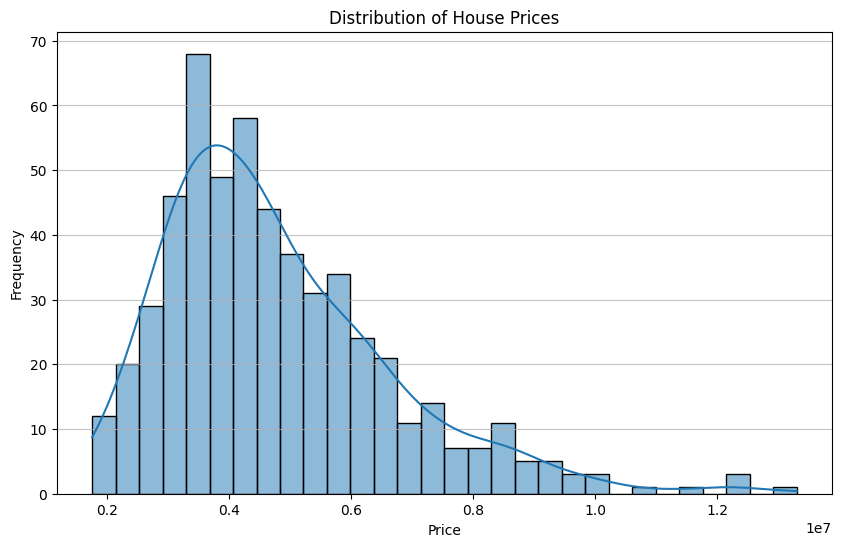

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_pandas_from_parquet['price'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

**Observations and Insights:**
- The distribution of house prices appears to be right-skewed, indicating that most houses are priced at the lower end, with fewer houses at very high prices.
- There's a concentration of houses in the lower to mid-price range, suggesting a market with a majority of moderately priced homes and a tail of luxury properties.

### Visualization 2: Scatter Plot of Area vs. Price

This scatter plot will help visualize the relationship between the `area` of a house and its `price`, identifying if there's a positive correlation as expected.

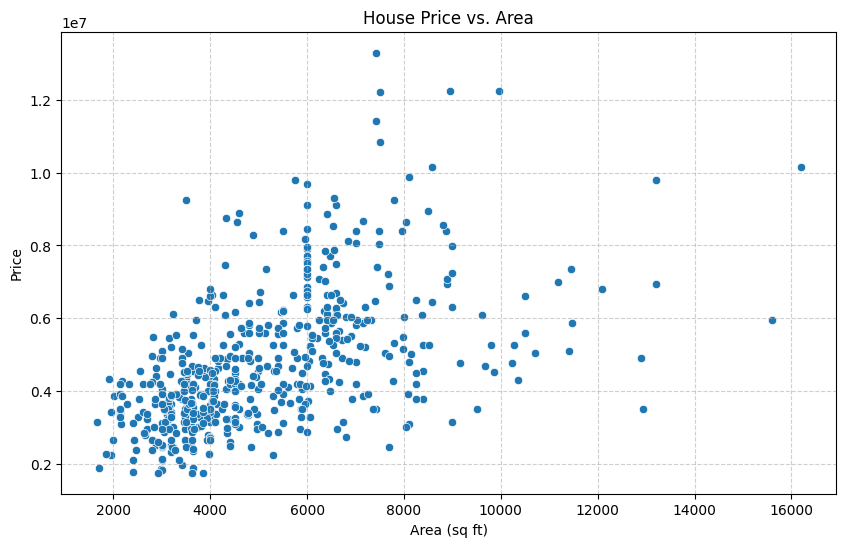

In [85]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area', y='price', data=df_pandas_from_parquet)
plt.title('House Price vs. Area')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Observations and Insights:**
- There is a clear positive correlation between house `area` and `price`. As the area of the house increases, its price generally tends to increase.
- The spread of prices also seems to widen with larger areas, indicating more variability in pricing for bigger homes, possibly due to other factors like location or amenities.

### Visualization 3: Bar Chart of Average Price by Number of Bedrooms

This bar chart will show the average price of houses based on the number of bedrooms, providing insight into how this feature impacts pricing.

/tmp/ipykernel_2533/410630489.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bedrooms', y='price', data=avg_price_by_bedrooms, palette='viridis')


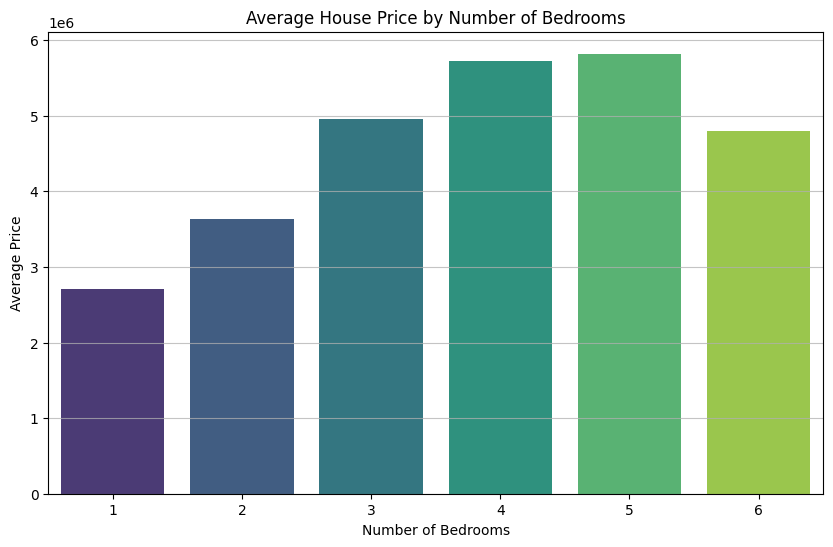

In [86]:
avg_price_by_bedrooms = df_pandas_from_parquet.groupby('bedrooms')['price'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='bedrooms', y='price', data=avg_price_by_bedrooms, palette='viridis')
plt.title('Average House Price by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Average Price')
plt.grid(axis='y', alpha=0.75)
plt.show()

**Observations and Insights:**
- Generally, the average house price increases with the number of bedrooms, which is an expected trend.
- There's a noticeable increase in average price from 1 to 4 bedrooms. The average price for 5 bedrooms is higher than 4 but seems to drop slightly for 6 bedrooms, which could be due to a smaller sample size for houses with more bedrooms or other confounding factors.

## 12. Machine Learning Model

In this section, we will build a machine learning model to predict house prices using the cleaned and processed data. We will follow these steps:
1.  Select an appropriate target column (`price`).
2.  Prepare features for the model.
3.  Split the data into training and testing sets.
4.  Train a regression model.
5.  Evaluate model performance.

### 12.1 Prepare Data for Modeling

We will use `price` as our target variable and select relevant features from our `df_pandas_from_parquet` DataFrame. We need to handle the `furnishingstatus_encoded` column, which is a PySpark vector, by converting it into separate columns suitable for scikit-learn.

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# The furnishingstatus_encoded column is a PySpark Vector, which is stored as an object in Pandas.
# We need to extract its dense vector representation and convert it to separate columns.
# Let's inspect its content first to understand its structure.
# Example: (2,[0],[1.0]) means a sparse vector of size 2, with value 1.0 at index 0.

# Determine the size of the vector (number of categories - 1 because dropLast=True was used in OHE)
# Assuming 3 original categories: 'furnished', 'semi-furnished', 'unfurnished'
# If 'furnished' is the dropped one, then index 0 could be 'semi-furnished' and index 1 'unfurnished'.
# Let's verify by inspecting a few entries.

# Create new columns for the one-hot encoded features
def get_ohe_value(vector_col, index):
    if vector_col is not None and isinstance(vector_col, tuple) and len(vector_col) == 3:
        # vector_col is (size, indices, values)
        indices = vector_col[1]
        values = vector_col[2]
        if index in indices:
            return values[indices.index(index)]
    return 0.0 # Default to 0 if not present or vector is sparse for this index

# Since dropLast=True, there are 2 features for 3 categories. Let's assume indices 0 and 1.
# You might need to adjust based on the exact output of your PySpark OHE.
# Based on the show(5) from silver layer: (2,[0],[1.0]) means the first index, so we need two columns
# for two possible indices, let's name them f_status_1 and f_status_2.

df_model = df_pandas_from_parquet.copy()

df_model['furnishingstatus_semi_furnished_ohe'] = df_model['furnishingstatus_encoded'].apply(lambda x: get_ohe_value(x, 0))
df_model['furnishingstatus_unfurnished_ohe'] = df_model['furnishingstatus_encoded'].apply(lambda x: get_ohe_value(x, 1))

# Drop the original furnishingstatus_encoded column as it's no longer needed
df_model = df_model.drop('furnishingstatus_encoded', axis=1)

# Define target and features
y = df_model['price']
X = df_model.drop('price', axis=1)

print("Features and Target prepared. First 5 rows of features:")
display(X.head())
print("First 5 rows of target:")
display(y.head())

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Features and Target prepared. First 5 rows of features:


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi_furnished_ohe,furnishingstatus_unfurnished_ohe
0,2880,3,1,2,1,0,0,0,0,0,1,0.0,0.0
1,5800,3,1,1,1,0,0,1,0,2,0,0.0,0.0
2,6240,4,2,2,1,0,0,0,1,1,0,0.0,0.0
3,8400,3,1,2,1,1,1,0,1,2,1,0.0,0.0
4,3000,3,2,2,1,1,1,0,0,0,0,0.0,0.0


First 5 rows of target:


,price
0,4403000
1,4200000
2,7070000
3,5250000
4,5110000


Shape of features (X): (545, 13)
Shape of target (y): (545,)


### 12.2 Split Data into Training and Testing Sets

We will split the data into 80% for training and 20% for testing to evaluate the model's performance on unseen data.

In [88]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets:
X_train shape: (436, 13)
X_test shape: (109, 13)
y_train shape: (436,)
y_test shape: (109,)


### 12.3 Train a Machine Learning Model

For this regression problem (predicting house `price`), we will use a simple Linear Regression model.

In [89]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")

Linear Regression model trained successfully.
Model coefficients: [2.29977290e+02 1.49587444e+05 9.53238609e+05 4.82316550e+05
 5.01239020e+05 3.54795181e+05 3.41279773e+05 9.72235003e+05
 8.92825358e+05 3.83904978e+05 6.10358366e+05 0.00000000e+00
 0.00000000e+00]
Model intercept: -276286.6910030125


### 12.4 Evaluate Model Performance

We will evaluate the model using common regression metrics: Mean Squared Error (MSE) and R-squared ($R^2$).

### 12.5 Improve Model Performance using Random Forest

To potentially improve the model's performance, we will now use a Random Forest Regressor, which is an ensemble learning method capable of handling non-linear relationships and interactions between features.

In [90]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
# You can tune hyperparameters like n_estimators, max_depth, etc., for better performance
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


### 12.6 Evaluate Random Forest Model Performance

We will evaluate the Random Forest model using the same regression metrics: Mean Squared Error (MSE) and R-squared ($R^2$).

Random Forest Model Evaluation:
Mean Squared Error (MSE): 1096366965777.43
R-squared (R2): 0.65


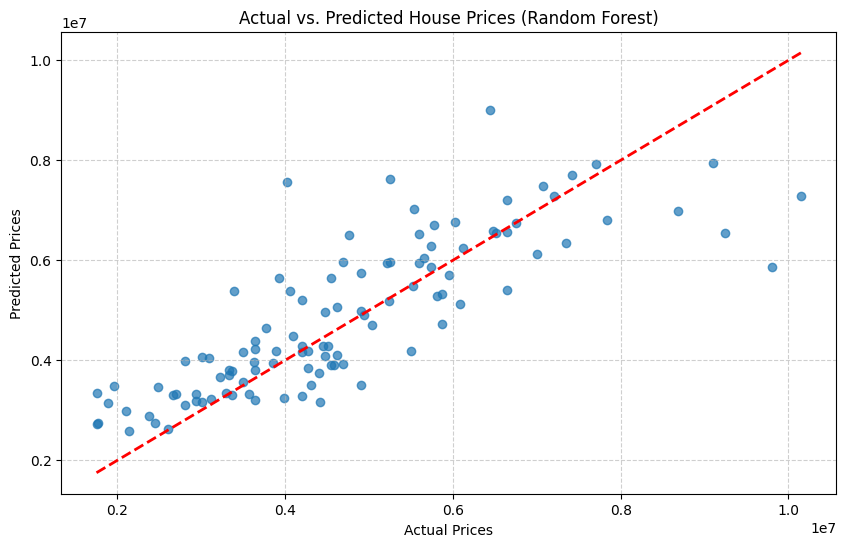

In [91]:
# Make predictions on the test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

# Visualize actual vs. predicted prices for Random Forest
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted House Prices (Random Forest)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Model Evaluation:
Mean Squared Error (MSE): 934360307567.97
R-squared (R2): 0.70


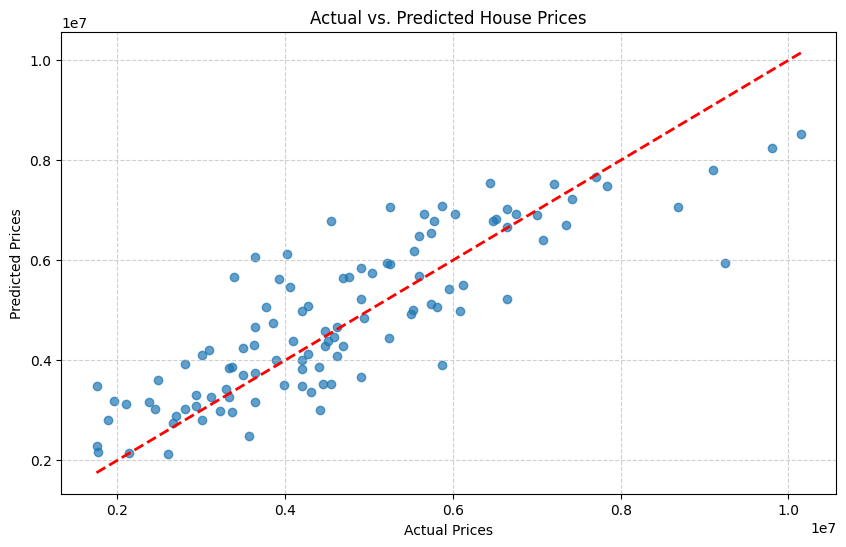

In [92]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize actual vs. predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted House Prices')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()